In [43]:
import numpy as np
import matplotlib.pyplot as plt

N_AIR = 1.0
scale = 0.58

curv = scale * np.array([83.6, 321.0, 44.8, -1150.0, 28.3, -38.5, 50.5, -53.2, 106.0, -120.0])
thick = scale * np.array([10.75, 15.55, 5.05, 5.05, 21.22, 13.9])
gaps = scale * np.array([1.65, 18.9, 0.97])
n_glass = [1.64238, 1.62306, 1.57566, 1.6727, 1.64238, 1.64238]

ratio = (thick.sum() + gaps.sum()) / 40.0
APERTURE_F_STOPS = np.array([2.0, 2.8, 4.0, 5.6, 8.0, 11.0, 16.0])
APERTURE_DIAMETERS_MM = np.array([3.0, 8.0, 12.0, 15.0, 17.2, 19.0, 20.0])
APERTURE_INDEX = len(APERTURE_DIAMETERS_MM) - 1  # widest setting for fully open aperture
APERTURE_RADIUS = 0.5 * APERTURE_DIAMETERS_MM[APERTURE_INDEX] * ratio

radii = 0.5 * np.array([41.5, 30.0, 20.0, 19.0, 25.0]) * ratio
LENS = list(zip(
    [curv[0], curv[1], curv[2], curv[3], curv[4], 0.0, curv[5], curv[6], curv[7], curv[8], curv[9]],
    [thick[0], gaps[0], thick[1], thick[2], gaps[1] * 0.5, gaps[1] * 0.5, thick[3], thick[4], gaps[2], thick[5], 0.0],
    [n_glass[0], N_AIR, n_glass[1], n_glass[2], N_AIR, N_AIR, n_glass[3], n_glass[4], N_AIR, n_glass[5], N_AIR],
    [radii[1], radii[1], radii[1], radii[1], radii[2], APERTURE_RADIUS, radii[3], radii[4], radii[4], radii[4], radii[4]]
))
LENS_LENGTH_MM = sum(seg[1] for seg in LENS)

def refract(direction, normal, eta):
    cos_i = -np.dot(normal, direction)
    sin2_t = eta * eta * (1.0 - cos_i * cos_i)
    if sin2_t > 1.0:
        return None
    cos_t = np.sqrt(max(0.0, 1.0 - sin2_t))
    return eta * direction + (eta * cos_i - cos_t) * normal

def intersect_surface(origin, direction, curvature, z_surface):
    if abs(curvature) < 1e-9:
        if abs(direction[2]) < 1e-12:
            return None
        t = (z_surface - origin[2]) / direction[2]
        if t <= 0.0:
            return None
        hit = origin + t * direction
        normal = np.array([0.0, 0.0, 1.0])
        if np.dot(direction, normal) > 0.0:
            normal = -normal
        return hit, normal
    radius = abs(curvature)
    center = np.array([0.0, 0.0, z_surface + curvature])
    oc = origin - center
    a = np.dot(direction, direction)
    b = np.dot(oc, direction)
    c = np.dot(oc, oc) - radius * radius
    disc = b * b - a * c
    if disc < 0.0:
        return None
    sqrt_disc = np.sqrt(disc)
    t0 = (-b - sqrt_disc) / a
    t1 = (-b + sqrt_disc) / a
    if t0 > t1:
        t0, t1 = t1, t0
    use_first = (direction[2] > 0.0) ^ (curvature < 0.0)
    t = t0 if use_first else t1
    if t <= 0.0:
        return None
    hit = origin + t * direction
    normal = hit - center
    normal /= np.linalg.norm(normal)
    if np.dot(direction, normal) > 0.0:
        normal = -normal
    return hit, normal

def trace_ray(ray_origin, target_point, record_path=False):
    origin = np.array(ray_origin, dtype=float)
    direction = np.array(target_point, dtype=float) - origin
    norm_dir = np.linalg.norm(direction)
    if norm_dir == 0.0:
        return None
    direction /= norm_dir
    path = [origin.copy()] if record_path else None
    z_surface = 0.0
    n_current = N_AIR
    for curvature, thickness, n_next, aperture in LENS:
        result = intersect_surface(origin, direction, curvature, z_surface)
        if result is None:
            return None
        hit, normal = result
        if aperture > 0.0 and hit[0] * hit[0] + hit[1] * hit[1] > aperture * aperture:
            return None
        eta = n_current / n_next
        refracted = refract(direction, normal, eta)
        if refracted is None:
            return None
        direction = refracted / np.linalg.norm(refracted)
        origin = hit
        if record_path:
            path.append(origin.copy())
        n_current = n_next
        z_surface += thickness
    return {
        "position": origin,
        "direction": direction,
        "path": np.vstack(path) if record_path else None
    }

def trace_ray_verbose(ray_origin, target_point):
    origin = np.array(ray_origin, dtype=float)
    direction = np.array(target_point, dtype=float) - origin
    path = [origin.copy()]
    norm_dir = np.linalg.norm(direction)
    if norm_dir == 0.0:
        return {
            "result": None,
            "path": np.vstack(path),
            "failure": "degenerate_direction",
            "failure_point": origin.copy()
        }
    direction /= norm_dir
    z_surface = 0.0
    n_current = N_AIR
    for curvature, thickness, n_next, aperture in LENS:
        result = intersect_surface(origin, direction, curvature, z_surface)
        if result is None:
            return {
                "result": None,
                "path": np.vstack(path),
                "failure": "surface_miss",
                "failure_point": path[-1].copy()
            }
        hit, normal = result
        path.append(hit.copy())
        if aperture > 0.0 and hit[0] * hit[0] + hit[1] * hit[1] > aperture * aperture:
            return {
                "result": None,
                "path": np.vstack(path),
                "failure": "aperture_clip",
                "failure_point": hit.copy()
            }
        eta = n_current / n_next
        refracted = refract(direction, normal, eta)
        if refracted is None:
            return {
                "result": None,
                "path": np.vstack(path),
                "failure": "total_internal_reflection",
                "failure_point": hit.copy()
            }
        direction = refracted / np.linalg.norm(refracted)
        origin = hit
        n_current = n_next
        z_surface += thickness
    path_array = np.vstack(path)
    result = {
        "position": origin,
        "direction": direction,
        "path": path_array
    }
    return {
        "result": result,
        "path": path_array,
        "failure": None,
        "failure_point": None
    }

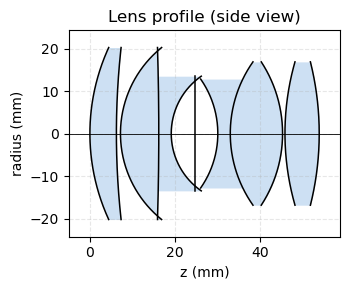

In [44]:
LENS_LENGTH_MM = sum(seg[1] for seg in LENS)


def spherical_profile(curvature, z_surface, aperture, samples=240):
    """Return z(r), r arrays for a spherical surface located at z_surface."""
    if aperture <= 0.0:
        return None
    r = np.linspace(-aperture, aperture, samples)
    if abs(curvature) < 1e-9:
        z = np.full_like(r, z_surface, dtype=float)
    else:
        radius = abs(curvature)
        z_center = z_surface + curvature
        sag = np.sqrt(np.clip(radius * radius - r * r, 0.0, None))
        z = z_center - np.sign(curvature) * sag
    return z, r


def add_lens_profile(ax, lens=LENS, *, samples=240, glass_color="#71a7dd", glass_alpha=0.35):
    surfaces = []
    z_surface = 0.0
    for curvature, thickness, n_next, aperture in lens:
        profile = spherical_profile(curvature, z_surface, aperture, samples=samples)
        surfaces.append((curvature, z_surface, aperture, n_next))
        if profile is not None:
            z_vals, r_vals = profile
            ax.plot(z_vals, r_vals, color="black", linewidth=1.1)
        z_surface += thickness

    for idx in range(len(surfaces) - 1):
        curvature_a, z_a, aperture_a, n_medium = surfaces[idx]
        curvature_b, z_b, aperture_b, _ = surfaces[idx + 1]
        if n_medium <= N_AIR + 1e-6:
            continue
        aperture_fill = min(aperture_a, aperture_b)
        if aperture_fill <= 0.0:
            continue
        profile_a = spherical_profile(curvature_a, z_a, aperture_fill, samples=samples)
        profile_b = spherical_profile(curvature_b, z_b, aperture_fill, samples=samples)
        if profile_a is None or profile_b is None:
            continue
        z_left, r_vals = profile_a
        z_right, _ = profile_b
        z_min = np.minimum(z_left, z_right)
        z_max = np.maximum(z_left, z_right)
        ax.fill_betweenx(r_vals, z_min, z_max, color=glass_color, alpha=glass_alpha, linewidth=0.0)
    return surfaces


# Example usage: create a figure, call the helper, and format the plot outside the function.
fig, ax = plt.subplots(figsize=(8.0, 3.0))
add_lens_profile(ax)
ax.axhline(0.0, color="black", linewidth=0.6)
ax.set_title("Lens profile (side view)")
ax.set_xlabel("z (mm)")
ax.set_ylabel("radius (mm)")
ax.set_xlim(-5.0, LENS_LENGTH_MM + 5.0)
ax.set_ylim(-APERTURE_RADIUS * 1.8, APERTURE_RADIUS * 1.8)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate focal distance to focal length conversion

In [45]:
def focus_from_two_rays(object_distance_mm, entry_scale=0.8, record_paths=False):
    origin = np.array([0.0, 0.0, -object_distance_mm], dtype=float)
    entry = entry_scale * APERTURE_RADIUS
    aims = (np.array([0.0, 0.0, 0.0]), np.array([entry, 0.0, 0.0]))
    rays = [trace_ray(origin, aim, record_paths) for aim in aims]
    if any(ray is None for ray in rays):
        return None
    p1, d1 = rays[0]["position"], rays[0]["direction"]
    p2, d2 = rays[1]["position"], rays[1]["direction"]
    a = np.dot(d1, d1)
    b = np.dot(d1, d2)
    c = np.dot(d2, d2)
    w0 = p1 - p2
    d = np.dot(d1, w0)
    e = np.dot(d2, w0)
    denom = a * c - b * b
    if abs(denom) < 1e-12:
        return None
    t1 = (b * e - c * d) / denom
    t2 = (a * e - b * d) / denom
    q1 = p1 + t1 * d1
    q2 = p2 + t2 * d2
    focus_point = 0.5 * (q1 + q2)
    result = {
        "point": focus_point,
        "residual_mm": np.linalg.norm(q1 - q2),
    }
    if record_paths:
        result["paths"] = [r["path"] for r in rays]
    return result

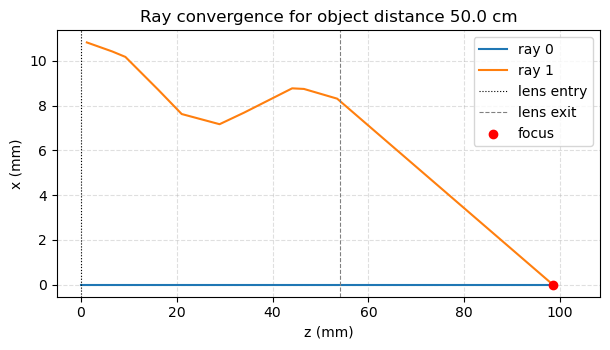

Object distance: 50.000 cm
Distance beyond lens exit: 44.504 mm
Ray intersection residual: 0.000 µm


In [46]:
object_distance_cm = 50.0
focus_info = focus_from_two_rays(object_distance_cm * 10.0, record_paths=True)

if focus_info is None:
    print("Ray tracing failed for the selected object distance.")
else:
    focus = focus_info["point"]
    residual_um = focus_info["residual_mm"] * 1e3

    plt.figure(figsize=(6.2, 3.6))
    for idx, path in enumerate(focus_info.get("paths", [])):
        segment = path[path[:, 2] >= -5.0]
        curve = np.vstack([segment, focus])
        plt.plot(curve[:, 2], curve[:, 0], label=f"ray {idx}")
    plt.axvline(0.0, color="black", linewidth=0.8, linestyle=":", label="lens entry")
    plt.axvline(LENS_LENGTH_MM, color="gray", linewidth=0.8, linestyle="--", label="lens exit")
    plt.scatter([focus[2]], [focus[0]], color="red", zorder=5, label="focus")
    plt.xlabel("z (mm)")
    plt.ylabel("x (mm)")
    plt.title(f"Ray convergence for object distance {object_distance_cm:.1f} cm")
    plt.xlim(-5.0, focus[2] * 1.1)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Object distance: {object_distance_cm:.3f} cm")
    print(f"Distance beyond lens exit: {focus[2] - LENS_LENGTH_MM:.3f} mm")
    print(f"Ray intersection residual: {residual_um:.3f} µm")

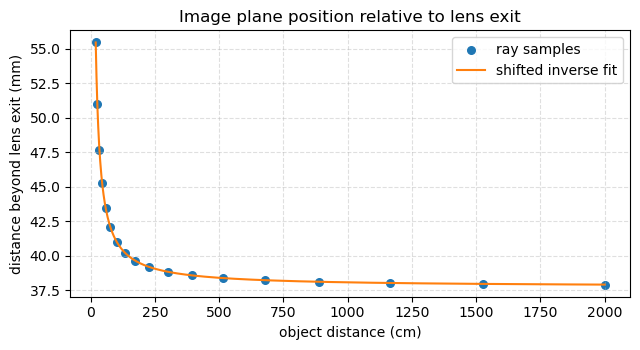

Rational function fit: f(x_cm) = a / (x_cm + b) + c
  a ≈ 326.903 mm·cm
  b ≈ -1.540 cm
  c ≈ 37.758 mm
  MSE ≈ 0.0000 mm^2


In [47]:
from scipy.optimize import curve_fit

object_distances_cm = np.geomspace(20.0, 2000.0, 18)
samples = []
for dist_cm in object_distances_cm:
    focus = focus_from_two_rays(dist_cm * 10.0)
    if focus is None or focus["residual_mm"] > 1e-3:
        continue
    samples.append((dist_cm, focus["point"][2] - LENS_LENGTH_MM))

if not samples:
    print("No focus samples collected.")
else:
    obj_cm, offset_mm = np.array(samples).T
    order = np.argsort(obj_cm)
    obj_cm = obj_cm[order]
    offset_mm = offset_mm[order]

    def rational_function_mm(x_cm, a, b, c):
        return a / (x_cm + b) + c

    popt, _ = curve_fit(rational_function_mm, obj_cm, offset_mm, p0=(5000.0, 0.0, 40.0), maxfev=20000)
    obj_fit = np.geomspace(obj_cm.min(), obj_cm.max(), 200)
    offset_fit = rational_function_mm(obj_fit, *popt)

    plt.figure(figsize=(6.5, 3.6))
    plt.scatter(obj_cm, offset_mm, s=30, label="ray samples")
    plt.plot(obj_fit, offset_fit, color="tab:orange", label="shifted inverse fit")
    plt.xlabel("object distance (cm)")
    plt.ylabel("distance beyond lens exit (mm)")
    plt.title("Image plane position relative to lens exit")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

    mse = float(np.mean((rational_function_mm(obj_cm, *popt) - offset_mm) ** 2))
    a_fit, b_fit, c_fit = popt
    print("Rational function fit: f(x_cm) = a / (x_cm + b) + c")
    print(f"  a ≈ {a_fit:.3f} mm·cm")
    print(f"  b ≈ {b_fit:.3f} cm")
    print(f"  c ≈ {c_fit:.3f} mm")
    print(f"  MSE ≈ {mse:.4f} mm^2")

In [48]:
def object_distance_cm_to_focal_length_mm(object_distance_cm):
    a, b, c = popt
    image_distance_mm = rational_function_mm(object_distance_cm, a, b, c) + LENS_LENGTH_MM
    return 1.0 / (1.0 / (object_distance_cm * 10.0) + 1.0 / image_distance_mm)

# Distort noise through the camera lens

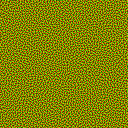

In [49]:
from PIL import Image
path = "C:\\Users\\ckobalt\\Documents\\MasterThesis\\Spatially-Varying-Bokeh\\bokehConfig\\5_fast_noise\\bokeh_fl45.0_as6_samples500000_od500_lidx0of8_0.png"

noisemap = Image.open(path)
display(noisemap)

In [50]:
object_distance_cm = 10.0
focal_length_mm = object_distance_cm_to_focal_length_mm(object_distance_cm)

sample_count = 1000

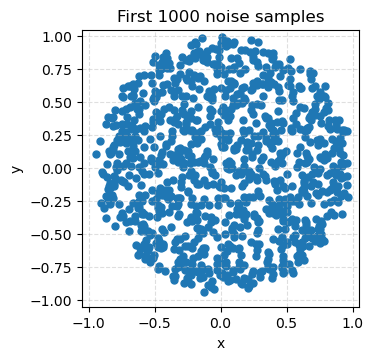

array([[ 0.32549024,  0.082353  ],
       [-0.56078434, -0.6784314 ],
       [-0.08235294,  0.45098042],
       ...,
       [ 0.27843142,  0.8039216 ],
       [-0.04313725, -0.3960784 ],
       [ 0.6784314 ,  0.39607847]], dtype=float32)

In [51]:
import numpy as np

# Map RGB channels from [0, 255] into [-1, 1] to interpret pixels as 2D positions.
pixel_data = np.asarray(noisemap, dtype=np.float32) / 255.0
flat_pixels = pixel_data.reshape(-1, pixel_data.shape[-1])
if flat_pixels.shape[1] < 2:
    raise ValueError("Noisemap must expose at least two channels for XY data.")
count = min(sample_count, flat_pixels.shape[0])
samples_xy = flat_pixels[:count, :2] * 2.0 - 1.0

fig, ax = plt.subplots(figsize=(3.6, 3.6))
ax.scatter(samples_xy[:, 0], samples_xy[:, 1], color="tab:blue", s=25)
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"First {count} noise samples")
ax.set_aspect('equal', adjustable='box')
ax.grid(True, linestyle="--", alpha=0.4)
plt.show()

samples_xy

In [52]:
grid_resolution = 50  # number of samples per axis
lin = np.linspace(-1.0, 1.0, grid_resolution, dtype=float)
grid_x, grid_y = np.meshgrid(lin, lin, indexing="xy")
#samples_xy = np.column_stack([grid_x.ravel(), grid_y.ravel()])
print(f"samples_xy grid shape: {samples_xy.shape}")

samples_xy grid shape: (1000, 2)


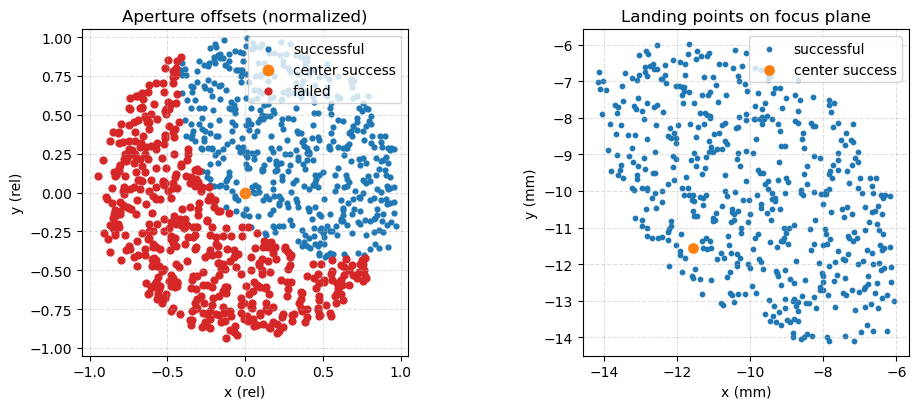

In [53]:
world_origin = np.array([20.0, 20.0, -object_distance_cm * 10.0], dtype=float)
focus_plane_z = 100.0  # mm plane where we inspect landings
opening_radii = radii[1] * 0.65

entry_offsets = np.vstack([samples_xy, np.zeros((1, 2), dtype=samples_xy.dtype)])
is_center = np.zeros(entry_offsets.shape[0], dtype=bool)
is_center[-1] = True
entry_points_xy_mm = entry_offsets * opening_radii
entry_points_mm = np.column_stack([entry_points_xy_mm, np.zeros(entry_offsets.shape[0])])

success_offsets = []
success_is_center = []
landing_points_xy = []
failed_offsets = []
failed_is_center = []

# Trace each aperture sample and classify it by whether it reaches the focus plane.
for offset_rel, entry_point_mm, center_flag in zip(entry_offsets, entry_points_mm, is_center):
    ray = trace_ray(world_origin, entry_point_mm, record_path=False)
    if ray is None:
        failed_offsets.append(offset_rel)
        failed_is_center.append(center_flag)
        continue

    last_pos = ray["position"]
    last_dir = ray["direction"]
    if abs(last_dir[2]) < 1e-9:
        failed_offsets.append(offset_rel)
        failed_is_center.append(center_flag)
        continue

    travel = (focus_plane_z - last_pos[2]) / last_dir[2]
    if travel <= 0.0:
        failed_offsets.append(offset_rel)
        failed_is_center.append(center_flag)
        continue

    landing_point = last_pos + travel * last_dir
    success_offsets.append(offset_rel)
    success_is_center.append(center_flag)
    landing_points_xy.append(landing_point[:2])

if success_offsets:
    success_offsets = np.asarray(success_offsets, dtype=float)
    success_is_center = np.asarray(success_is_center, dtype=bool)
    landing_xy_mm = np.asarray(landing_points_xy, dtype=float)
else:
    success_offsets = np.empty((0, 2), dtype=float)
    success_is_center = np.zeros(0, dtype=bool)
    landing_xy_mm = np.empty((0, 2), dtype=float)

if failed_offsets:
    failed_offsets = np.asarray(failed_offsets, dtype=float)
    failed_is_center = np.asarray(failed_is_center, dtype=bool)
else:
    failed_offsets = np.empty((0, 2), dtype=float)
    failed_is_center = np.zeros(0, dtype=bool)

landing_is_center = success_is_center

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))

if success_offsets.size:
    non_center_success = success_offsets[~landing_is_center]
    if non_center_success.size:
        axes[0].scatter(non_center_success[:, 0], non_center_success[:, 1], s=12, color="tab:blue", label="successful")
    if landing_is_center.any():
        axes[0].scatter(0.0, 0.0, s=55, color="tab:orange", label="center success")

if failed_offsets.size:
    non_center_fail = failed_offsets[~failed_is_center]
    if non_center_fail.size:
        axes[0].scatter(non_center_fail[:, 0], non_center_fail[:, 1], s=24, color="tab:red", label="failed")
    if failed_is_center.any():
        axes[0].scatter(0.0, 0.0, s=65, color="tab:red", marker="x", linewidths=1.0, label="center failed")

axes[0].set_title("Aperture offsets (normalized)")
axes[0].set_xlabel("x (rel)")
axes[0].set_ylabel("y (rel)")
axes[0].set_xlim(-1.05, 1.05)
axes[0].set_ylim(-1.05, 1.05)
axes[0].set_aspect("equal", adjustable="box")
axes[0].grid(True, linestyle="--", alpha=0.4)
axes[0].legend(loc="upper right")

if landing_xy_mm.size:
    non_center_landings = landing_xy_mm[~landing_is_center]
    if non_center_landings.size:
        axes[1].scatter(non_center_landings[:, 0], non_center_landings[:, 1], s=10, color="tab:blue", label="successful")
    if landing_is_center.any():
        center_landing = landing_xy_mm[landing_is_center][0]
        axes[1].scatter(center_landing[0], center_landing[1], s=45, color="tab:orange", label="center success")
else:
    axes[1].text(0.5, 0.5, "No rays reached focus plane", ha="center", va="center", transform=axes[1].transAxes)

axes[1].set_title("Landing points on focus plane")
axes[1].set_xlabel("x (mm)")
axes[1].set_ylabel("y (mm)")
axes[1].set_aspect("equal", adjustable="box")
axes[1].grid(True, linestyle="--", alpha=0.4)
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()


In [54]:
film_plane_radius = 5.9  # mm

scaled_entry_xy = success_offsets * film_plane_radius
if landing_is_center.any():
    landing_center_xy = landing_xy_mm[landing_is_center][0]
else:
    landing_center_xy = np.zeros(2)
    print("Warning: center ray did not reach focus plane; using origin for centering.")
landing_centered_xy = landing_xy_mm - landing_center_xy
abs_diff_xy = np.abs(landing_centered_xy - scaled_entry_xy)
entry_radius = np.linalg.norm(scaled_entry_xy, axis=1)
landing_radius = np.linalg.norm(landing_centered_xy, axis=1)
abs_radius_diff = np.abs(landing_radius - entry_radius)
comparison = {
    "scaled_entry_xy": scaled_entry_xy,
    "landing_centered_xy": landing_centered_xy,
    "abs_diff_xy": abs_diff_xy,
    "entry_radius": entry_radius,
    "landing_radius": landing_radius,
    "abs_radius_diff": abs_radius_diff,
    "is_center": success_is_center.copy(),
}
print(f"Samples compared: {scaled_entry_xy.shape[0]}")
print(f"Mean |Δx|: {abs_diff_xy[:, 0].mean():.4f} mm, Mean |Δy|: {abs_diff_xy[:, 1].mean():.4f} mm")
print(f"Mean radius shift: {abs_radius_diff.mean():.4f} mm")

Samples compared: 513
Mean |Δx|: 0.1504 mm, Mean |Δy|: 0.1497 mm
Mean radius shift: 0.1875 mm


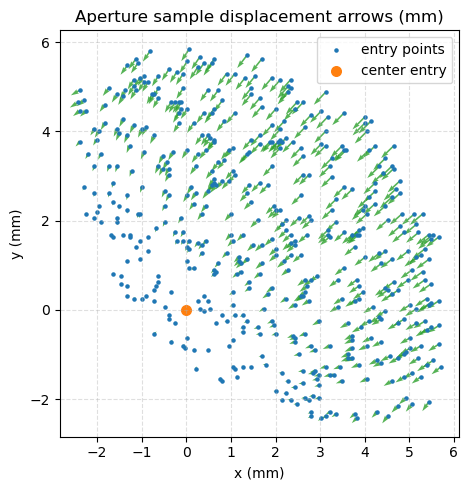

In [55]:
entry_xy = comparison["scaled_entry_xy"]
landing_xy = comparison["landing_centered_xy"]
delta_xy = landing_xy - entry_xy
is_center = comparison["is_center"]
plt.figure(figsize=(5.0, 5.0))
plt.quiver(
    entry_xy[:, 0],
    entry_xy[:, 1],
    delta_xy[:, 0],
    delta_xy[:, 1],
    angles="xy",
    scale_units="xy",
    scale=1.0,
    width=0.004,
    color="tab:green",
    alpha=0.8
)
plt.scatter(entry_xy[~is_center, 0], entry_xy[~is_center, 1], s=5, color="tab:blue", label="entry points")
if is_center.any():
    plt.scatter(entry_xy[is_center, 0], entry_xy[is_center, 1], s=48, color="tab:orange", label="center entry")
plt.title("Aperture sample displacement arrows (mm)")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

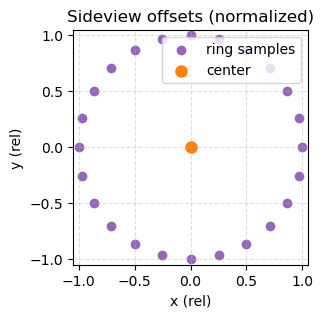

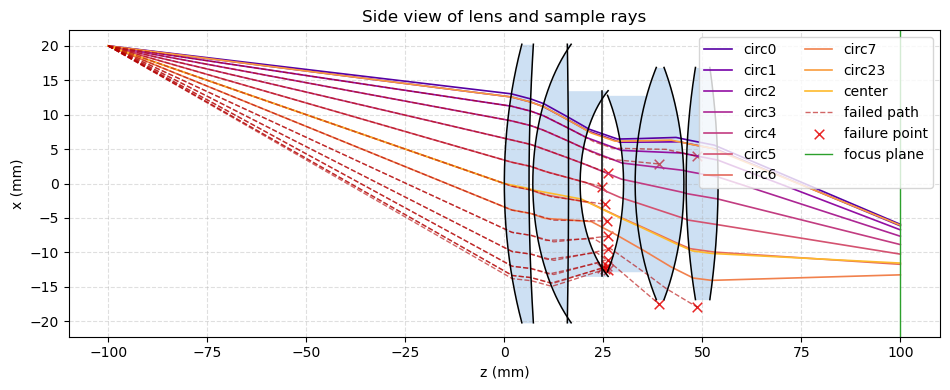

In [56]:
circle_count = 24
angles = np.linspace(0.0, 2.0 * np.pi, circle_count, endpoint=False)
sideview_offsets = np.vstack([np.column_stack([np.cos(angles), np.sin(angles)]), np.zeros((1, 2))])
sideview_labels = [f"circ{i}" for i in range(circle_count)] + ["center"]

plt.figure(figsize=(3.4, 3.4))
plt.scatter(sideview_offsets[:-1, 0], sideview_offsets[:-1, 1], s=36, color="tab:purple", label="ring samples")
plt.scatter(0.0, 0.0, s=64, color="tab:orange", label="center")
plt.title("Sideview offsets (normalized)")
plt.xlabel("x (rel)")
plt.ylabel("y (rel)")
plt.xlim(-1.05, 1.05)
plt.ylim(-1.05, 1.05)
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

sideview_success_paths = []
sideview_success_labels = []
sideview_failure_paths = []
sideview_failure_points = []

for offset, label in zip(sideview_offsets, sideview_labels):
    
    entry_point_mm = np.array([offset[0] * opening_radii, offset[1] * opening_radii, 0.0])
    ray_info = trace_ray_verbose(world_origin, entry_point_mm)
    result = ray_info["result"]
    path = ray_info["path"]

    if result is None:
        sideview_failure_paths.append(path)
        sideview_failure_points.append(ray_info["failure_point"])
        continue

    last_pos = result["position"]
    last_dir = result["direction"]
    if abs(last_dir[2]) < 1e-9:
        sideview_failure_paths.append(path)
        sideview_failure_points.append(path[-1])
        continue

    travel = (focus_plane_z - last_pos[2]) / last_dir[2]
    if travel <= 0.0:
        sideview_failure_paths.append(path)
        sideview_failure_points.append(path[-1])
        continue

    landing_point = last_pos + travel * last_dir
    sideview_success_paths.append(np.vstack([path, landing_point]))
    sideview_success_labels.append(label)

if sideview_success_paths or sideview_failure_paths:
    fig, ax = plt.subplots(figsize=(9.6, 4.0))

    # Plot successful ray paths
    if sideview_success_paths:
        colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(sideview_success_paths)))
        for path, label, color in zip(sideview_success_paths, sideview_success_labels, colors):
            ax.plot(path[:, 2], path[:, 0], color=color, linewidth=1.2, label=label)

    # Plot failed ray paths and failure points
    failed_path_color = (0.7, 0.0, 0.0, 0.6)
    failed_point_color = (0.9, 0.0, 0.0, 0.85)
    for idx, (path, point) in enumerate(zip(sideview_failure_paths, sideview_failure_points)):
        label_line = "failed path" if idx == 0 else None
        label_point = "failure point" if idx == 0 else None
        if path is not None and path.size:
            ax.plot(path[:, 2], path[:, 0], color=failed_path_color, linewidth=1.0, linestyle="--", label=label_line)
        if point is not None:
            ax.scatter(point[2], point[0], color=failed_point_color, s=48, marker="x", linewidths=1.1, label=label_point)

    # Plot lens profile
    add_lens_profile(ax)

    ax.axvline(focus_plane_z, color="tab:green", linewidth=1, label="focus plane")
    ax.set_title("Side view of lens and sample rays")
    ax.set_xlabel("z (mm)")
    ax.set_ylabel("x (mm)")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(loc="upper right", ncol=2)
    plt.tight_layout()
    plt.show()